# MNIST Classification Demo

This notebook demonstrates the usage of MnistClassifier with three algorithms: Random Forest (rf), Feed-Forward Neural Network (nn), and Convolutional Neural Network (cnn).

## Imports

In [1]:
import numpy as np
from torchvision import datasets
from torchvision import transforms
from mnist_classifier import MnistClassifier

## Load, prepare data

In [2]:
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_dataset = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)

print(train_dataset.data.shape)
print(test_dataset.data.shape)

torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])


In [3]:
X_train = train_dataset.data.numpy()
y_train = train_dataset.targets.numpy()

X_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()

## Random Forest

In [4]:
clf_rf = MnistClassifier(algorithm='rf')
clf_rf.train(X_train, y_train)

preds_rf = clf_rf.predict(X_test)

accuracy_rf = np.mean(preds_rf == y_test)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")

Random Forest Accuracy: 0.9705


## Feed-Forward Neural Network

In [5]:
clf_nn = MnistClassifier(algorithm='nn')
clf_nn.train(X_train, y_train)

preds_nn = clf_nn.predict(X_test)

accuracy_nn = np.mean(preds_nn == y_test)
print(f"Feed-Forward NN Accuracy: {accuracy_nn:.4f}")

Epoch 1/10, Loss: 0.0107
Epoch 1/10, Loss: 0.0188
Epoch 1/10, Loss: 0.0277
Epoch 1/10, Loss: 0.0342
Epoch 1/10, Loss: 0.0401
Epoch 1/10, Loss: 0.0473
Epoch 1/10, Loss: 0.0546
Epoch 1/10, Loss: 0.0587
Epoch 1/10, Loss: 0.0649
Epoch 1/10, Loss: 0.0704
Epoch 1/10, Loss: 0.0748
Epoch 1/10, Loss: 0.0787
Epoch 1/10, Loss: 0.0833
Epoch 1/10, Loss: 0.0870
Epoch 1/10, Loss: 0.0912
Epoch 1/10, Loss: 0.0948
Epoch 1/10, Loss: 0.0988
Epoch 1/10, Loss: 0.1033
Epoch 1/10, Loss: 0.1078
Epoch 1/10, Loss: 0.1121
Epoch 1/10, Loss: 0.1160
Epoch 1/10, Loss: 0.1188
Epoch 1/10, Loss: 0.1219
Epoch 1/10, Loss: 0.1250
Epoch 1/10, Loss: 0.1278
Epoch 1/10, Loss: 0.1313
Epoch 1/10, Loss: 0.1344
Epoch 1/10, Loss: 0.1372
Epoch 1/10, Loss: 0.1401
Epoch 1/10, Loss: 0.1428
Epoch 1/10, Loss: 0.1453
Epoch 1/10, Loss: 0.1488
Epoch 1/10, Loss: 0.1506
Epoch 1/10, Loss: 0.1530
Epoch 1/10, Loss: 0.1557
Epoch 1/10, Loss: 0.1577
Epoch 1/10, Loss: 0.1596
Epoch 1/10, Loss: 0.1616
Epoch 1/10, Loss: 0.1638
Epoch 1/10, Loss: 0.1653


## Convolutional Neural Network

In [6]:
clf_cnn = MnistClassifier(algorithm='cnn')
clf_cnn.train(X_train, y_train)

preds_cnn = clf_cnn.predict(X_test)

accuracy_cnn = np.mean(preds_cnn == y_test)
print(f"CNN Accuracy: {accuracy_cnn:.4f}")

Epoch 1/10, loss=0.1906
Epoch 2/10, loss=0.0542
Epoch 3/10, loss=0.0336
Epoch 4/10, loss=0.0211
Epoch 5/10, loss=0.0149
Epoch 6/10, loss=0.0120
Epoch 7/10, loss=0.0082
Epoch 8/10, loss=0.0065
Epoch 9/10, loss=0.0051
Epoch 10/10, loss=0.0058
CNN Accuracy: 0.9900


## Result Comparison

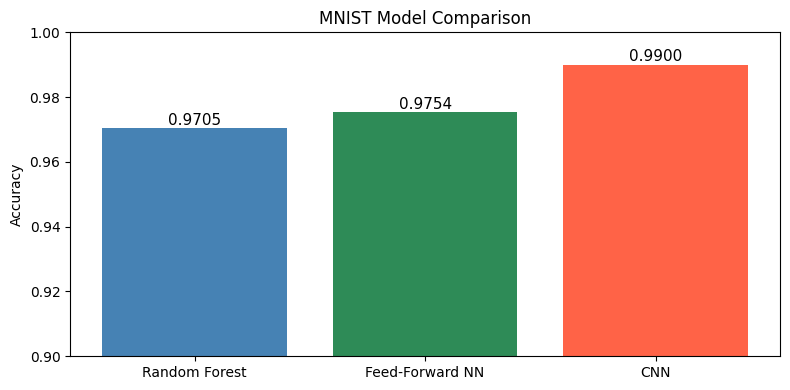

In [7]:
import matplotlib.pyplot as plt

models     = ['Random Forest', 'Feed-Forward NN', 'CNN']
accuracies = [accuracy_rf, accuracy_nn, accuracy_cnn]

plt.figure(figsize=(8, 4))
bars = plt.bar(models, accuracies, color=['steelblue', 'seagreen', 'tomato'])
plt.ylim(0.9, 1.0)
plt.ylabel('Accuracy')
plt.title('MNIST Model Comparison')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{acc:.4f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Edge cases

In [8]:
single_image = X_test[0:1]
print(f"Input shape: {single_image.shape}")

for algo in ['rf', 'nn', 'cnn']:
    clf = MnistClassifier(algorithm=algo)
    clf.train(X_train, y_train)
    pred = clf.predict(single_image)
    print(f"[{algo}] Predicted: {pred[0]}, Ground truth: {y_test[0]}")

Input shape: (1, 28, 28)
[rf] Predicted: 7, Ground truth: 7
Epoch 1/10, Loss: 0.0100
Epoch 1/10, Loss: 0.0187
Epoch 1/10, Loss: 0.0253
Epoch 1/10, Loss: 0.0342
Epoch 1/10, Loss: 0.0410
Epoch 1/10, Loss: 0.0468
Epoch 1/10, Loss: 0.0513
Epoch 1/10, Loss: 0.0552
Epoch 1/10, Loss: 0.0597
Epoch 1/10, Loss: 0.0652
Epoch 1/10, Loss: 0.0695
Epoch 1/10, Loss: 0.0729
Epoch 1/10, Loss: 0.0771
Epoch 1/10, Loss: 0.0802
Epoch 1/10, Loss: 0.0830
Epoch 1/10, Loss: 0.0863
Epoch 1/10, Loss: 0.0902
Epoch 1/10, Loss: 0.0937
Epoch 1/10, Loss: 0.0959
Epoch 1/10, Loss: 0.0998
Epoch 1/10, Loss: 0.1026
Epoch 1/10, Loss: 0.1057
Epoch 1/10, Loss: 0.1083
Epoch 1/10, Loss: 0.1114
Epoch 1/10, Loss: 0.1149
Epoch 1/10, Loss: 0.1174
Epoch 1/10, Loss: 0.1201
Epoch 1/10, Loss: 0.1223
Epoch 1/10, Loss: 0.1251
Epoch 1/10, Loss: 0.1274
Epoch 1/10, Loss: 0.1299
Epoch 1/10, Loss: 0.1325
Epoch 1/10, Loss: 0.1343
Epoch 1/10, Loss: 0.1365
Epoch 1/10, Loss: 0.1386
Epoch 1/10, Loss: 0.1405
Epoch 1/10, Loss: 0.1423
Epoch 1/10, Los

In [9]:
try:
    clf_bad = MnistClassifier(algorithm='svm')
except ValueError as e:
    print(f"Caught expected error: {e}")

Caught expected error: Unknown algorithm 'svm'. Choose from: ['rf', 'nn', 'cnn']


In [10]:
try:
    clf_untrained = MnistClassifier(algorithm='rf')
    clf_untrained.predict(X_test[:5])
except Exception as e:
    print(f"Caught expected error: {type(e).__name__}: {e}")

Caught expected error: NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.


In [11]:
X_small = X_train[:500]
y_small = y_train[:500]

for algo in ['rf', 'nn', 'cnn']:
    clf = MnistClassifier(algorithm=algo)
    clf.train(X_small, y_small)
    preds = clf.predict(X_test[:100])
    acc = np.mean(preds == y_test[:100])
    print(f"[{algo}] Small subset test accuracy (500 train samples): {acc:.4f}")

[rf] Small subset test accuracy (500 train samples): 0.8400
Epoch 1/10, Loss: 1.3457
Epoch 1/10, Loss: 2.3556
Epoch 1/10, Loss: 3.2840
Epoch 1/10, Loss: 4.1220
Epoch 1/10, Loss: 5.1032
Epoch 1/10, Loss: 5.8762
Epoch 1/10, Loss: 6.5249
Epoch 1/10, Loss: 7.2767
Epoch 1/10, Loss: 7.9093
Epoch 1/10, Loss: 8.4713
Epoch 1/10, Loss: 8.9940
Epoch 1/10, Loss: 9.5386
Epoch 1/10, Loss: 10.0792
Epoch 1/10, Loss: 10.6128
Epoch 1/10, Loss: 11.1712
Epoch 1/10, Loss: 11.7405
Epoch 2/10, Loss: 0.4288
Epoch 2/10, Loss: 0.8033
Epoch 2/10, Loss: 1.3125
Epoch 2/10, Loss: 1.8576
Epoch 2/10, Loss: 2.1968
Epoch 2/10, Loss: 2.4807
Epoch 2/10, Loss: 2.8170
Epoch 2/10, Loss: 3.2075
Epoch 2/10, Loss: 3.5404
Epoch 2/10, Loss: 3.8976
Epoch 2/10, Loss: 4.1976
Epoch 2/10, Loss: 4.4877
Epoch 2/10, Loss: 4.7739
Epoch 2/10, Loss: 5.0830
Epoch 2/10, Loss: 5.3196
Epoch 2/10, Loss: 5.5942
Epoch 3/10, Loss: 0.2293
Epoch 3/10, Loss: 0.4895
Epoch 3/10, Loss: 0.7429
Epoch 3/10, Loss: 0.9293
Epoch 3/10, Loss: 1.1273
Epoch 3/10,